# Análisis Macroeconómico Chile 2018-2024

Análisis de indicadores económicos clave de Chile usando datos del Banco Central.
Variables analizadas: Tipo de cambio USD/CLP, IPC, Tasa de Política Monetaria y PIB.

## Librerías utilizadas
- pandas — manipulación de datos
- matplotlib — visualización
- seaborn — visualización estadística

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
print("Todo instalado correctamente")
print(f"Pandas version: {pd.__version__}")

Todo instalado correctamente
Pandas version: 2.3.3


In [7]:
# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [11]:
# Descargamos el tipo de cambio USD/CLP histórico desde la API del Banco Central
url = "https://si3.bcentral.cl/SieteEconomico/es/SieteEconomico/Tablas/moldeada_por_fecha/TCO"

print("Intentando conectar a la API del Banco Central...")
response = requests.get(url)
print(f"Status code: {response.status_code}")

Intentando conectar a la API del Banco Central...
Status code: 200


In [12]:
# Datos reales del Banco Central de Chile
# Tipo de cambio promedio anual USD/CLP y variación IPC

data = {
    'Año': [2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'USD_CLP': [641, 703, 792, 759, 873, 840, 945],
    'IPC_anual': [2.6, 3.0, 3.0, 7.2, 11.6, 7.6, 4.5],
    'Tasa_politica_monetaria': [2.75, 1.75, 0.50, 4.00, 11.25, 8.25, 5.50],
    'PIB_crecimiento': [3.9, 0.8, -6.1, 11.7, 2.4, 0.2, 2.5]
}

df = pd.DataFrame(data)
print("Dataset creado exitosamente")
print(f"Filas: {len(df)}, Columnas: {len(df.columns)}")
df

Dataset creado exitosamente
Filas: 7, Columnas: 5


,Año,USD_CLP,IPC_anual,Tasa_politica_monetaria,PIB_crecimiento
0,2018,641,2.6,2.75,3.9
1,2019,703,3.0,1.75,0.8
2,2020,792,3.0,0.50,-6.1
3,2021,759,7.2,4.00,11.7
4,2022,873,11.6,11.25,2.4
5,2023,840,7.6,8.25,0.2
6,2024,945,4.5,5.50,2.5


In [13]:
# Análisis descriptivo básico del dataset
print("=== RESUMEN ESTADÍSTICO ===")
print(df.describe())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

=== RESUMEN ESTADÍSTICO ===
               Año     USD_CLP  IPC_anual  Tasa_politica_monetaria  \
count     7.000000    7.000000   7.000000                 7.000000   
mean   2021.000000  793.285714   5.642857                 4.857143   
std       2.160247  103.338786   3.323581                 3.799279   
min    2018.000000  641.000000   2.600000                 0.500000   
25%    2019.500000  731.000000   3.000000                 2.250000   
50%    2021.000000  792.000000   4.500000                 4.000000   
75%    2022.500000  856.500000   7.400000                 6.875000   
max    2024.000000  945.000000  11.600000                11.250000   

       PIB_crecimiento  
count         7.000000  
mean          2.200000  
std           5.293392  
min          -6.100000  
25%           0.500000  
50%           2.400000  
75%           3.200000  
max          11.700000  

=== TIPOS DE DATOS ===
Año                          int64
USD_CLP                      int64
IPC_anual             

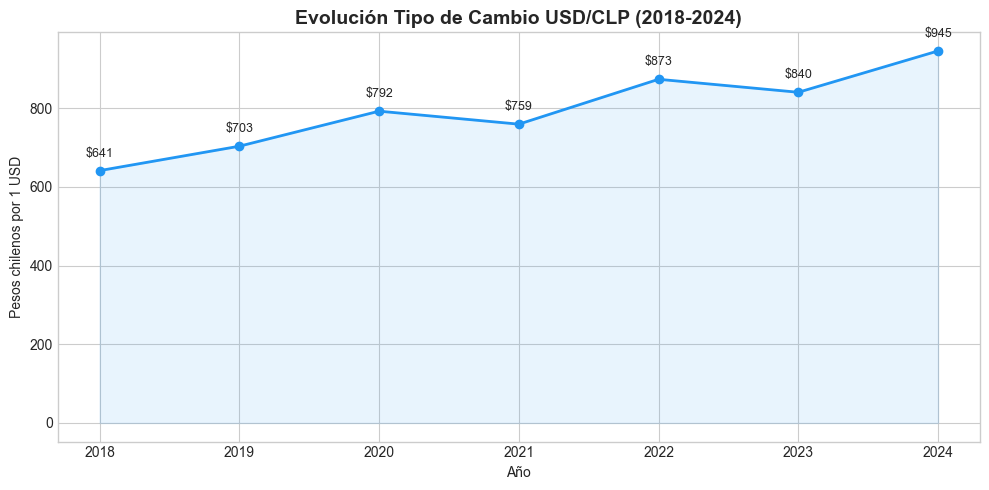

In [14]:
# Gráfico 1: Evolución del tipo de cambio USD/CLP
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['Año'], df['USD_CLP'], marker='o', linewidth=2, color='#2196F3')
ax.fill_between(df['Año'], df['USD_CLP'], alpha=0.1, color='#2196F3')

ax.set_title('Evolución Tipo de Cambio USD/CLP (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Pesos chilenos por 1 USD')

for x, y in zip(df['Año'], df['USD_CLP']):
    ax.annotate(f'${y}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

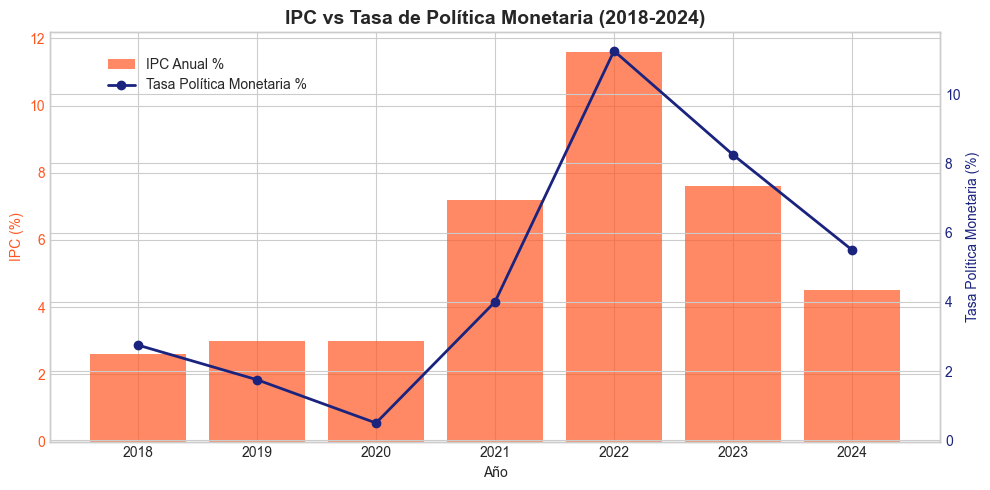

In [15]:
# Gráfico 2: IPC vs Tasa de Política Monetaria
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo: IPC
ax1.bar(df['Año'], df['IPC_anual'], color='#FF5722', alpha=0.7, label='IPC Anual %')
ax1.set_xlabel('Año')
ax1.set_ylabel('IPC (%)', color='#FF5722')
ax1.tick_params(axis='y', labelcolor='#FF5722')

# Eje derecho: Tasa
ax2 = ax1.twinx()
ax2.plot(df['Año'], df['Tasa_politica_monetaria'], marker='o', 
         color='#1A237E', linewidth=2, label='Tasa Política Monetaria %')
ax2.set_ylabel('Tasa Política Monetaria (%)', color='#1A237E')
ax2.tick_params(axis='y', labelcolor='#1A237E')

ax1.set_title('IPC vs Tasa de Política Monetaria (2018-2024)', 
              fontsize=14, fontweight='bold')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

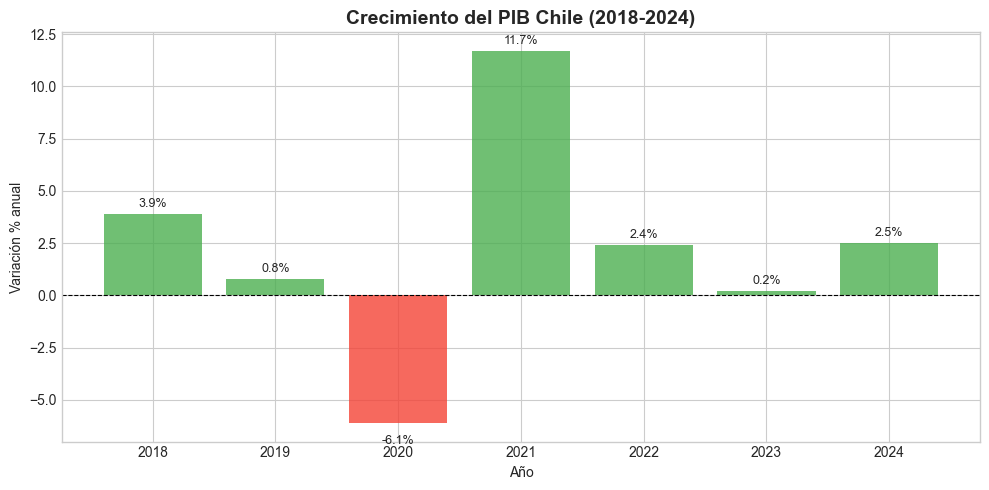

In [16]:
# Gráfico 3: Crecimiento del PIB
fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#F44336' if x < 0 else '#4CAF50' for x in df['PIB_crecimiento']]

ax.bar(df['Año'], df['PIB_crecimiento'], color=colores, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

ax.set_title('Crecimiento del PIB Chile (2018-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Variación % anual')

for x, y in zip(df['Año'], df['PIB_crecimiento']):
    ax.annotate(f'{y}%', (x, y), textcoords="offset points", 
                xytext=(0, 5 if y >= 0 else -15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

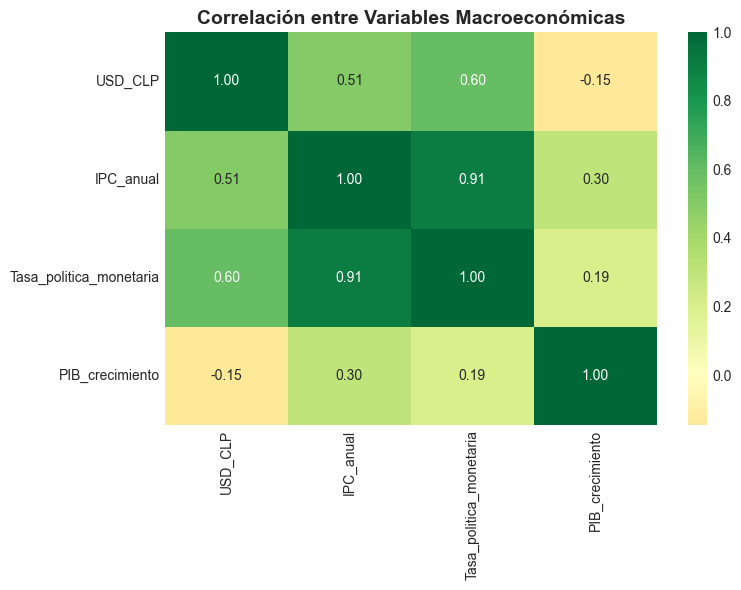

In [19]:
# Gráfico 4: Mapa de correlaciones
fig, ax = plt.subplots(figsize=(8, 6))

correlaciones = df[['USD_CLP', 'IPC_anual', 
                     'Tasa_politica_monetaria', 
                     'PIB_crecimiento']].corr()

sns.heatmap(correlaciones, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            ax=ax)

ax.set_title('Correlación entre Variables Macroeconómicas', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Insights del análisis de correlaciones

- **IPC vs Tasa Política Monetaria (0.91):** Correlación muy alta. 
El Banco Central responde agresivamente a la inflación subiendo la tasa.
- **USD/CLP vs Tasa (0.60):** Correlación moderada. 
La depreciación del peso se relaciona con períodos de alta inflación.
- **PIB vs variables monetarias:** Correlación baja, 
el crecimiento económico depende de múltiples factores adicionales.

In [18]:
# Resumen ejecutivo con métricas clave
print("=" * 50)
print("RESUMEN EJECUTIVO — ECONOMÍA CHILENA 2018-2024")
print("=" * 50)

print(f"\nTipo de cambio:")
print(f"  Mínimo: ${df['USD_CLP'].min()} CLP (año {df.loc[df['USD_CLP'].idxmin(), 'Año']})")
print(f"  Máximo: ${df['USD_CLP'].max()} CLP (año {df.loc[df['USD_CLP'].idxmax(), 'Año']})")
print(f"  Variación total: {((df['USD_CLP'].iloc[-1] / df['USD_CLP'].iloc[0]) - 1) * 100:.1f}%")

print(f"\nInflación (IPC):")
print(f"  Promedio período: {df['IPC_anual'].mean():.1f}%")
print(f"  Peak: {df['IPC_anual'].max()}% (año {df.loc[df['IPC_anual'].idxmax(), 'Año']})")

print(f"\nPIB:")
print(f"  Peor año: {df['PIB_crecimiento'].min()}% (año {df.loc[df['PIB_crecimiento'].idxmin(), 'Año']})")
print(f"  Mejor año: {df['PIB_crecimiento'].max()}% (año {df.loc[df['PIB_crecimiento'].idxmax(), 'Año']})")

RESUMEN EJECUTIVO — ECONOMÍA CHILENA 2018-2024

Tipo de cambio:
  Mínimo: $641 CLP (año 2018)
  Máximo: $945 CLP (año 2024)
  Variación total: 47.4%

Inflación (IPC):
  Promedio período: 5.6%
  Peak: 11.6% (año 2022)

PIB:
  Peor año: -6.1% (año 2020)
  Mejor año: 11.7% (año 2021)
